## **Učitavanje biblioteka**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import pearsonr, spearmanr

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [2]:
import os
os.makedirs('slike', exist_ok=True)  # folder za grafike

## **Učitavanje podataka**

In [3]:
df = pd.read_csv('14_cardiovascular_disease_dataset.csv')
df.head(10)


,age,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,50,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,55,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,51,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,48,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,47,1,156,56.0,100,60,1,1,0,0,0,0
5,21914,60,1,151,67.0,120,80,2,2,0,0,0,0
6,22113,60,1,157,93.0,130,80,3,1,0,0,1,0
7,22584,61,2,178,95.0,130,90,3,3,0,0,1,1
8,17668,48,1,158,71.0,110,70,1,1,0,0,1,0
9,19834,54,1,164,68.0,110,60,1,1,0,0,0,0


### **Eliminacija nedostajućih vrednosti**

In [4]:
print("Nedostajuće vrednosti po kolonama:\n", df.isnull().sum())
#nemamo NaN vrednosti

Nedostajuće vrednosti po kolonama:
 age            0
age_years      0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### **Eliminacija pogrešnih vrednosti**


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
age_years,70000.0,52.840671,6.766774,29.0,48.0,53.0,58.0,64.0
gender,70000.0,1.349571,0.476838,1.0,1.0,1.0,2.0,2.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0


In [6]:
df['ap_hi'] = df['ap_hi'].where(df['ap_hi'] > 0, np.nan)
df['ap_lo'] = df['ap_lo'].where(df['ap_lo'] > 0, np.nan)
#imamo 29 pacijenata sa pogrešnim vrednostima od 70000, dovoljno mali procenat
#da možemo da ih izbacinmo
df = df.dropna() # Brišemo pacijente iz cele baze

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,69971.0,19468.928299,2466.989497,10798.0,17664.0,19703.0,21327.0,23713.0
age_years,69971.0,52.840820,6.766078,29.0,48.0,53.0,58.0,64.0
gender,69971.0,1.349516,0.476821,1.0,1.0,1.0,2.0,2.0
height,69971.0,164.359363,8.210512,55.0,159.0,165.0,170.0,250.0
weight,69971.0,74.208362,14.395224,10.0,65.0,72.0,82.0,200.0
ap_hi,69971.0,128.779066,153.858001,1.0,120.0,120.0,140.0,16020.0
ap_lo,69971.0,96.663603,188.502998,1.0,80.0,80.0,90.0,11000.0
cholesterol,69971.0,1.366909,0.680286,1.0,1.0,1.0,2.0,3.0
gluc,69971.0,1.226522,0.572332,1.0,1.0,1.0,1.0,3.0
smoke,69971.0,0.088137,0.283495,0.0,0.0,0.0,0.0,1.0


### **Kvalitativne promenljive**

In [8]:
kvalitativne_kolone = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
y = df['cardio'] #izlazna
kvalitativne = df[kvalitativne_kolone]
kvalitativne.head(10)

,gender,cholesterol,gluc,smoke,alco,active
0,2,1,1,0,0,1
1,1,3,1,0,0,1
2,1,3,1,0,0,0
3,2,1,1,0,0,1
4,1,1,1,0,0,0
5,1,2,2,0,0,0
6,1,3,1,0,0,1
7,2,3,3,0,0,1
8,1,1,1,0,0,1
9,1,1,1,0,0,0


### **Enkodovanje kvalitativnih promenljivih**

In [9]:

# 2. Definišemo koje kolone zapravo želimo da razbijemo na One-Hot.
# (Napomena: kolone smoke, alco i active su već binarne 0/1, pa nema potrebe
# da ih razbijamo na dve dodatne kolone. Zato enkodujemo samo gender, cholesterol i gluc)
kolone_za_enkodiranje = ['gender', 'cholesterol', 'gluc']

# 3. Primenjujemo One-Hot enkodiranje
kvalitativne_onehot = pd.get_dummies(kvalitativne, columns=kolone_za_enkodiranje, drop_first=True, dtype=int)

# Provera rezultata
print(kvalitativne_onehot.head(10))

   smoke  alco  active  gender_2  cholesterol_2  cholesterol_3  gluc_2  gluc_3
0      0     0       1         1              0              0       0       0
1      0     0       1         0              0              1       0       0
2      0     0       0         0              0              1       0       0
3      0     0       1         1              0              0       0       0
4      0     0       0         0              0              0       0       0
5      0     0       0         0              1              0       1       0
6      0     0       1         0              0              1       0       0
7      0     0       1         1              0              1       0       1
8      0     0       1         0              0              0       0       0
9      0     0       0         0              0              0       0       0


## **Kvantitativne** **promenljive**

In [10]:
#Kolona age_years predstavlja linearnu transformaciju kolone age, pa je kolona age uklonjena zbog redundantnosti.
kvantitativne_kolone = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']


kvantitativne = df[kvantitativne_kolone]

# Provera - ispisuje prvih 5 redova novog skupa
print(kvantitativne.head())



   age_years  height  weight  ap_hi  ap_lo
0         50     168    62.0  110.0   80.0
1         55     156    85.0  140.0   90.0
2         51     165    64.0  130.0   70.0
3         48     169    82.0  150.0  100.0
4         47     156    56.0  100.0   60.0


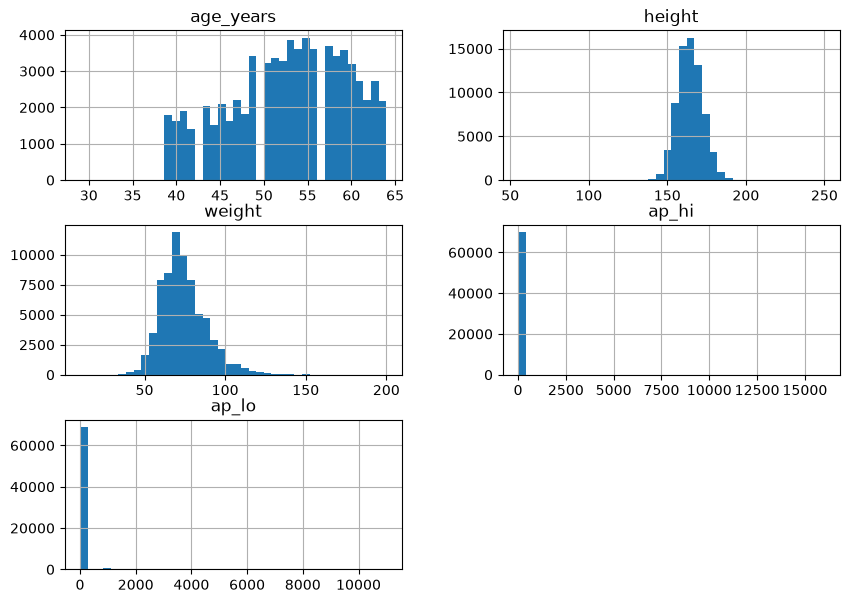

In [11]:
kvantitativne.hist(figsize=(10,7), bins=40)
plt.show()

### **Eliminacija outlier-a**

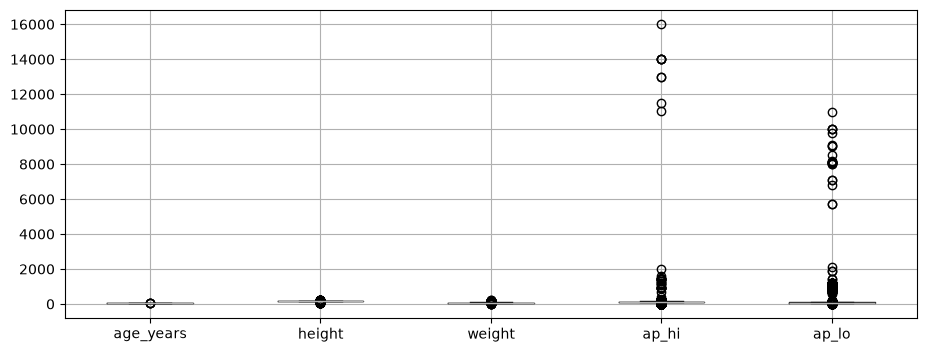

In [11]:
kvantitativne.boxplot(figsize=(11,4))
plt.show()

In [12]:
Q1 = kvantitativne.quantile(0.25)
Q3 = kvantitativne.quantile(0.75)
IQR = Q3 - Q1

kvantitativne = kvantitativne.clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR, axis=1)
kvantitativne.describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,69971.0,52.841034,6.765389,33.0,48.0,53.0,58.0,64.0
height,69971.0,164.407333,7.825969,142.5,159.0,165.0,170.0,186.5
weight,69971.0,73.928234,13.441478,39.5,65.0,72.0,82.0,107.5
ap_hi,69971.0,126.712552,16.376841,90.0,120.0,120.0,140.0,170.0
ap_lo,69971.0,81.785097,9.059412,65.0,80.0,80.0,90.0,105.0


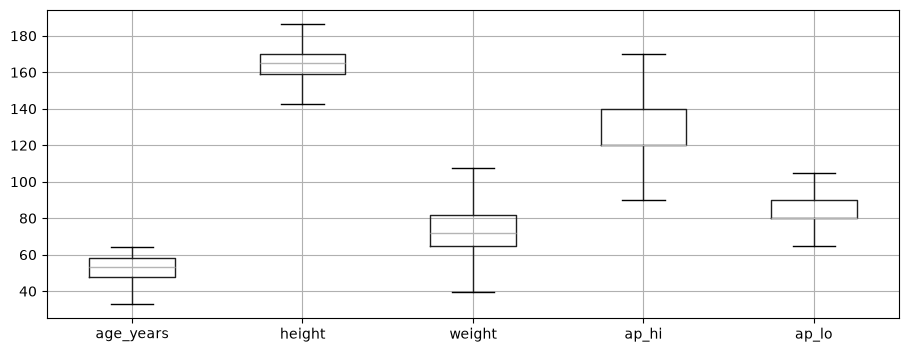

In [13]:
kvantitativne.boxplot(figsize=(11,4))
plt.show()

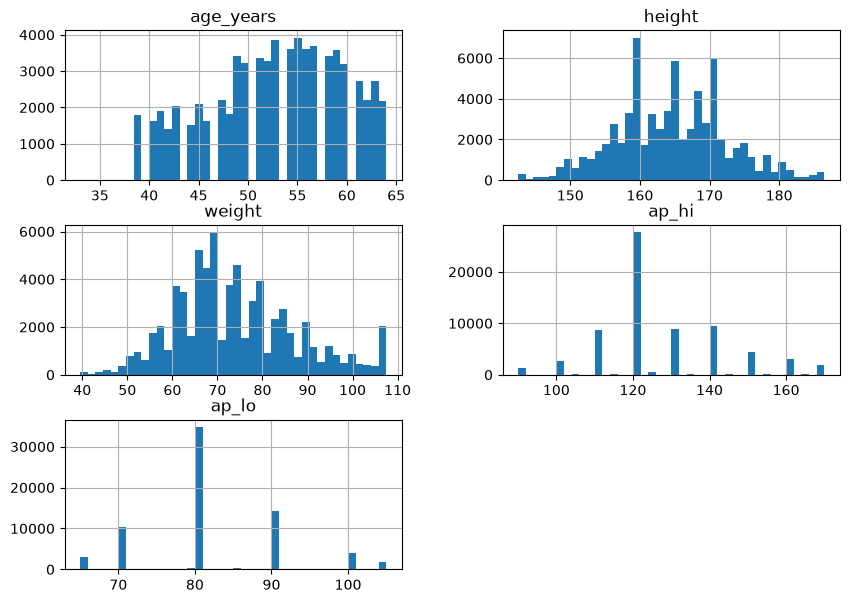

In [14]:
kvantitativne.hist(figsize=(10,7), bins=40)
plt.show()

# **Selekcija obeležja**

In [15]:
df_clean = pd.concat([kvantitativne, kvalitativne_onehot, y], axis=1)

In [16]:
def calculateInfoD(col):
    un, cnt = np.unique(col, return_counts=True)
    infoD = 0
    for i in range(len(un)):
        p = cnt[i] / len(col)
        infoD -= p*np.log2(p)
    return infoD

In [17]:
klasa = df_clean.iloc[:,-1]

infoD = calculateInfoD(klasa)
print('Info(D) = ' + str(infoD))

Info(D) = 0.9999998395512723


In [18]:
brojKoraka = 20
IG = []
for ob in range(df_clean.shape[1]-1):
    kol = df_clean.iloc[:, ob]
    f = np.unique(kol)

    if len(f) > brojKoraka:
        korak = (max(kol) - min(kol))/brojKoraka
        kol = np.floor(kol/korak)*korak
        f = np.unique(kol)

    infoDA = 0
    for i in f:
        temp = klasa[kol == i]

        infoDi = calculateInfoD(temp)
        Di = sum(kol == i)
        D = len(kol)

        infoDA += Di*infoDi/D

    IG.append([df_clean.columns[ob], infoD - infoDA])

IGdf = pd.DataFrame(IG, columns=['obelezje', 'IG'])
IGsorted = IGdf.sort_values(by=['IG'], ascending=False, ignore_index=True)
IGsorted

,obelezje,IG
0,ap_hi,0.168830
1,ap_lo,0.106189
2,age_years,0.044175
3,cholesterol_3,0.027792
4,weight,0.025528
5,cholesterol_2,0.004812
6,gluc_3,0.003585
7,gluc_2,0.002023
8,active,0.000915
9,height,0.000674


### **Deset najreprezentativnijih obeležja**

In [19]:
top_10 = IGsorted['obelezje'].head(10).tolist()
X_top10 = df_clean[top_10]

# Provera nove baze
X_top10.head()

,ap_hi,ap_lo,age_years,cholesterol_3,weight,cholesterol_2,gluc_3,gluc_2,active,height
0,110.0,80.0,50,0,62.0,0,0,0,1,168.0
1,140.0,90.0,55,1,85.0,0,0,0,1,156.0
2,130.0,70.0,51,1,64.0,0,0,0,0,165.0
3,150.0,100.0,48,0,82.0,0,0,0,1,169.0
4,100.0,65.0,47,0,56.0,0,0,0,0,156.0


### **Međusobna korelacija - Pearsonova metoda**

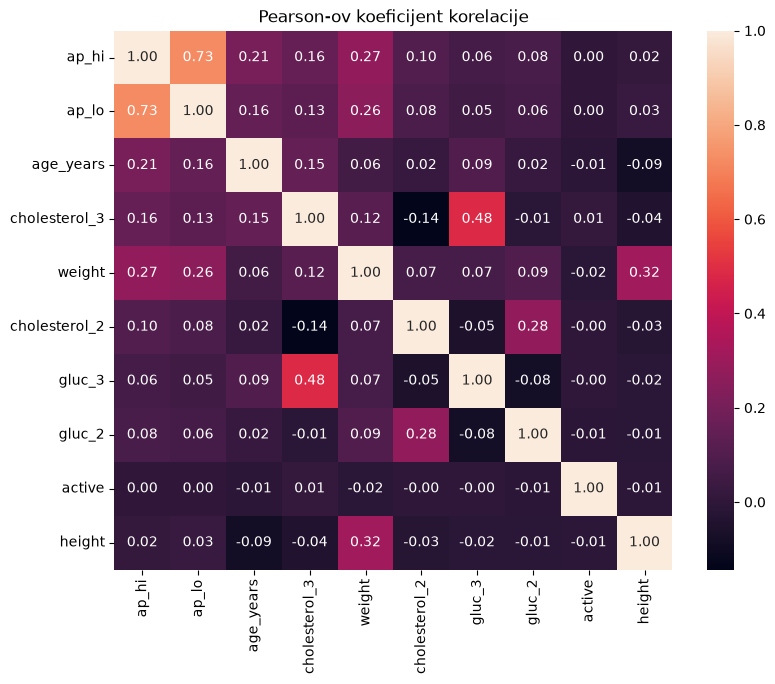

In [20]:
pearson_R = X_top10.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(pearson_R, annot=True, fmt=".2f")
plt.title('Pearson-ov koeficijent korelacije')
plt.yticks(rotation=0)
plt.savefig('slike/korelaciona_matrica.png', dpi=200, bbox_inches='tight')
plt.show()

### **Raspodela vrednosti korelacionih koeficijenata**

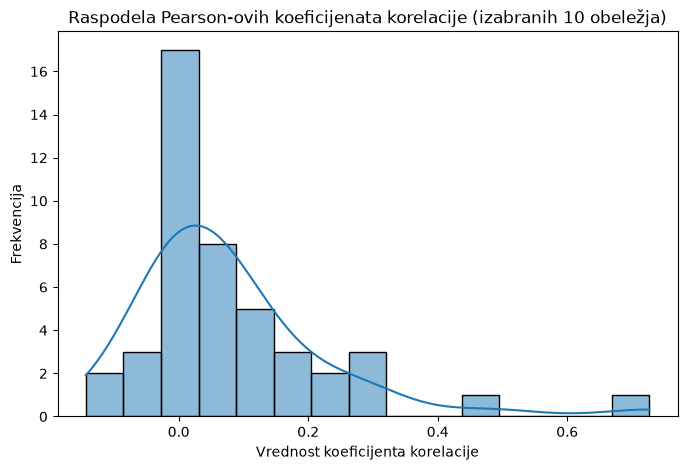

Prosečna apsolutna korelacija: 0.105
Maksimalna apsolutna korelacija: 0.727


In [21]:
# Raspodela vrednosti Pearson-ovih koeficijenata korelacije za izabranih 10 obeležja
# Uzimamo samo gornji trougao matrice bez dijagonale (k=1), da ne dupliramo parove

mask = np.triu(np.ones(pearson_R.shape), k=1).astype(bool)
korelacioni_koeficijenti = pearson_R.values[mask]

plt.figure(figsize=(8, 5))
sns.histplot(korelacioni_koeficijenti, bins=15, kde=True)
plt.title('Raspodela Pearson-ovih koeficijenata korelacije (izabranih 10 obeležja)')
plt.xlabel('Vrednost koeficijenta korelacije')
plt.ylabel('Frekvencija')
plt.savefig('slike/raspodela_korelacije.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Prosečna apsolutna korelacija: {np.mean(np.abs(korelacioni_koeficijenti)):.3f}")
print(f"Maksimalna apsolutna korelacija: {np.max(np.abs(korelacioni_koeficijenti)):.3f}")

Dva obeležja sa najvećom korelacijom sa klasom (od izabranih 10) su: 1. ap_hi i 2. ap_lo


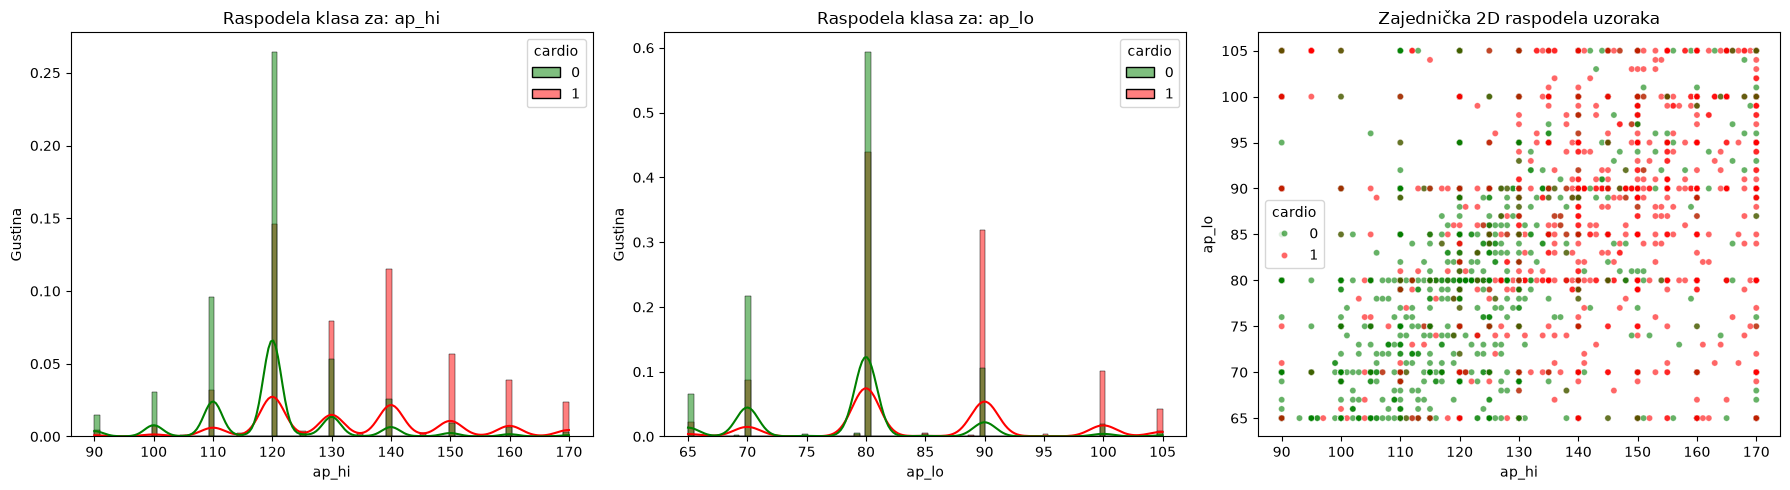

In [22]:

top10_sa_klasom = pd.concat([X_top10, y], axis=1)
korelacije_sa_klasom = top10_sa_klasom.corr()['cardio'].drop('cardio').abs()

# Izdvajamo imena dva obeležja sa najvećom vrednošću
top2_obelezja = korelacije_sa_klasom.sort_values(ascending=False).head(2).index.tolist()

print(f"Dva obeležja sa najvećom korelacijom sa klasom (od izabranih 10) su: 1. {top2_obelezja[0]} i 2. {top2_obelezja[1]}")

# Vizuelizacija raspodele
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
sns.histplot(data=df_clean, x=top2_obelezja[0], hue='cardio', kde=True, palette=['green', 'red'], alpha=0.5, stat='density')
plt.title(f'Raspodela klasa za: {top2_obelezja[0]}', fontsize=12)
plt.xlabel(top2_obelezja[0])
plt.ylabel('Gustina')

plt.subplot(1, 3, 2)
sns.histplot(data=df_clean, x=top2_obelezja[1], hue='cardio', kde=True, palette=['green', 'red'], alpha=0.5, stat='density')
plt.title(f'Raspodela klasa za: {top2_obelezja[1]}', fontsize=12)
plt.xlabel(top2_obelezja[1])
plt.ylabel('Gustina')


plt.subplot(1, 3, 3)
sns.scatterplot(data=df_clean, x=top2_obelezja[0], y=top2_obelezja[1], hue='cardio', palette=['green', 'red'], alpha=0.6, s=20)
plt.title(f'Zajednička 2D raspodela uzoraka', fontsize=12)
plt.xlabel(top2_obelezja[0])
plt.ylabel(top2_obelezja[1])

plt.tight_layout()
#plt.savefig('slike/raspodela_klasa.png', dpi=200, bbox_inches='tight')
plt.show()

## **Redukcija dimenzija**

In [23]:
X = df_clean.iloc[:, :-1]
y = df_clean[df_clean.columns[-1]]

X.describe()

,age_years,height,weight,ap_hi,ap_lo,smoke,alco,active,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3
count,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000,69971.000000
mean,52.841034,164.407333,73.928234,126.712552,81.785097,0.088137,0.053779,0.803704,0.349516,0.136414,0.115248,0.074174,0.076174
std,6.765389,7.825969,13.441478,16.376841,9.059412,0.283495,0.225584,0.397198,0.476821,0.343230,0.319323,0.262055,0.265279
min,33.000000,142.500000,39.500000,90.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,58.000000,170.000000,82.000000,140.000000,90.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,64.000000,186.500000,107.500000,170.000000,105.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### **Normalizacija podataka**

In [24]:
m = np.mean(X, axis=0)
std = np.std(X, axis=0)

Xnorm = (X - m) / std
Xnorm.describe()


,age_years,height,weight,ap_hi,ap_lo,smoke,alco,active,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3
count,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04,6.997100e+04
mean,6.336606e-17,-1.909106e-16,-2.737739e-16,2.613850e-16,5.752196e-16,-9.748625e-18,-1.624771e-17,2.437156e-18,1.716164e-17,-5.483601e-17,3.452638e-17,-7.311469e-18,3.015981e-17
std,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00,1.000007e+00
min,-2.932747e+00,-2.799332e+00,-2.561361e+00,-2.241752e+00,-1.852793e+00,-3.108945e-01,-2.384031e-01,-2.023452e+00,-7.330194e-01,-3.974441e-01,-3.609154e-01,-2.830478e-01,-2.871505e-01
25%,-7.155640e-01,-6.909523e-01,-6.642348e-01,-4.098837e-01,-1.970447e-01,-3.108945e-01,-2.384031e-01,4.942050e-01,-7.330194e-01,-3.974441e-01,-3.609154e-01,-2.830478e-01,-2.871505e-01
50%,2.349710e-02,7.573135e-02,-1.434550e-01,-4.098837e-01,-1.970447e-01,-3.108945e-01,-2.384031e-01,4.942050e-01,-7.330194e-01,-3.974441e-01,-3.609154e-01,-2.830478e-01,-2.871505e-01
75%,7.625582e-01,7.146344e-01,6.005161e-01,8.113617e-01,9.067876e-01,-3.108945e-01,-2.384031e-01,4.942050e-01,1.364220e+00,-3.974441e-01,-3.609154e-01,-2.830478e-01,-2.871505e-01
max,1.649432e+00,2.823015e+00,2.497643e+00,2.643230e+00,2.562536e+00,3.216525e+00,4.194577e+00,4.942050e-01,1.364220e+00,2.516077e+00,2.770733e+00,3.532972e+00,3.482494e+00


### **LDA (Linear Discriminant Analysis)**

Kumulativna varijansa po dimenzijama: [1.01471772]
Minimalan broj dimenzija za > 80% varijanse: 1
Kontrolna provera (solver='svd', bez shrinkage): [1.]


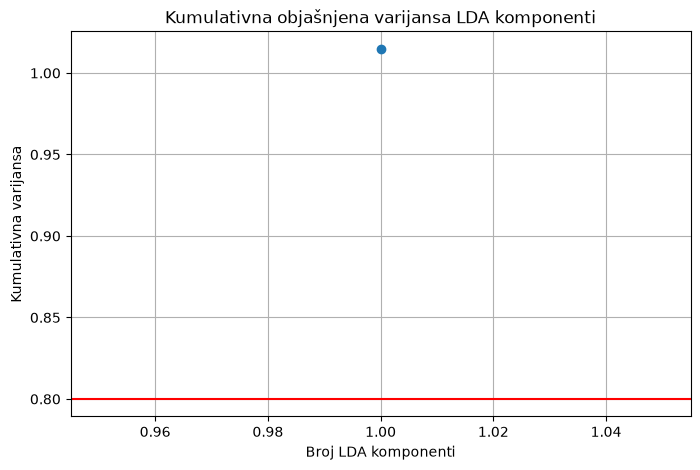

In [25]:
lda = LDA(solver='eigen', shrinkage='auto')
lda.fit(Xnorm, y)

explained_variance = lda.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Određivanje minimalnog broja dimenzija za > 80%
n_components = np.argmax(cumulative_variance >= 0.80) + 1

print(f"Kumulativna varijansa po dimenzijama: {cumulative_variance}")
print(f"Minimalan broj dimenzija za > 80% varijanse: {n_components}")


lda_svd = LDA(solver='svd')
lda_svd.fit(Xnorm, y)
print(f"Kontrolna provera (solver='svd', bez shrinkage): {lda_svd.explained_variance_ratio_}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-')
plt.title('Kumulativna objašnjena varijansa LDA komponenti')
plt.xlabel('Broj LDA komponenti')
plt.ylabel('Kumulativna varijansa')
plt.grid(True)
#plt.savefig('slike/lda_varijansa.png', dpi=200, bbox_inches='tight')
plt.show()

## Testiranje hipoteza i parametarska klasifikacija

### Provera separabilnosti klasa na LDA projekciji

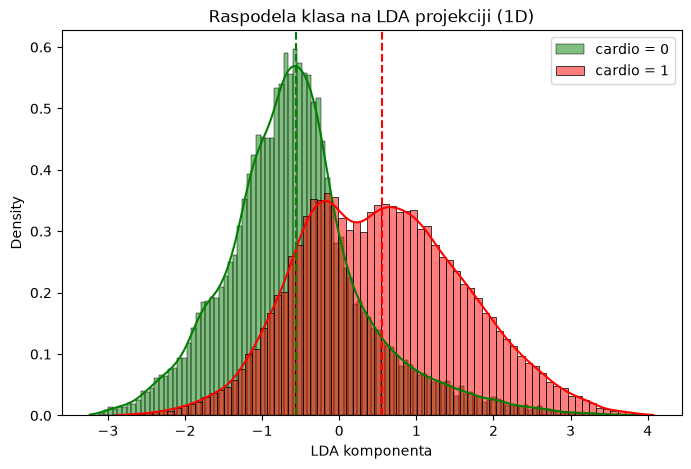

Sredina klase 0: -0.555, varijansa: 0.852
Sredina klase 1: 0.556, varijansa: 1.150
Fisher-ov diskriminacioni odnos: 0.617

=> Umerena separabilnost - linearni klasifikator je moguć, ali očekujte primetno preklapanje/grešku.


In [ ]:
# Projektujemo podatke na 1D LDA osu (transform vraća skalarnu vrednost po uzorku)
lda_proj = lda.transform(Xnorm).ravel()

klasa0 = lda_proj[y == 0]
klasa1 = lda_proj[y == 1]

# Vizuelna provera separabilnosti - koliko se raspodele klasa preklapaju
plt.figure(figsize=(8, 5))
sns.histplot(klasa0, color='green', label='cardio = 0', kde=True, stat='density', alpha=0.5)
sns.histplot(klasa1, color='red', label='cardio = 1', kde=True, stat='density', alpha=0.5)
plt.axvline(klasa0.mean(), color='green', linestyle='--')
plt.axvline(klasa1.mean(), color='red', linestyle='--')
plt.title('Raspodela klasa na LDA projekciji (1D)')
plt.xlabel('LDA komponenta')
plt.legend()
#plt.savefig('slike/lda_separabilnost.png', dpi=200, bbox_inches='tight')
plt.show()

# Kvantitativna mera separabilnosti - Fisher-ov diskriminacioni odnos
m0, m1 = klasa0.mean(), klasa1.mean()
v0, v1 = klasa0.var(), klasa1.var()
fisher_ratio = (m0 - m1) ** 2 / (v0 + v1)


print(f"Sredina klase 0: {m0:.3f}, varijansa: {v0:.3f}")
print(f"Sredina klase 1: {m1:.3f}, varijansa: {v1:.3f}")
print(f"Fisher-ov diskriminacioni odnos: {fisher_ratio:.3f}")

if fisher_ratio > 1.0:
    print("\n=> Klase su solidno separabilne na LDA projekciji - dovoljan je linearni klasifikator (1D prag).")
elif fisher_ratio > 0.3:
    print("\n=> Umerena separabilnost - linearni klasifikator je moguć.")
else:
    print("\n=> Slaba separabilnost na LDA projekciji - razmotriti IG-bazirana obeležja (npr. ap_hi, ap_lo) u više dimenzija.")

Fisher odnos ≈ 0.617 → umerena separabilnost. Biramo **linearni klasifikator na bazi željenog izlaza** primenjen na LDA projekciju.

### Podela na trening/test skup
LDA se ponovo trenira SAMO na trening skupu, da test skup ostane potpuno nezavisan.

In [27]:
from sklearn.model_selection import train_test_split

# Podela 80/20, stratifikovano po klasi da očuvamo odnos cardio=0/1 u oba skupa
X_train, X_test, y_train, y_test = train_test_split(
    Xnorm, y, test_size=0.2, random_state=42, stratify=y
)
y_train = np.array(y_train)
y_test = np.array(y_test)

# LDA se trenira isključivo na trening skupu
lda_final = LDA(solver='eigen', shrinkage='auto')
lda_final.fit(X_train, y_train)

proj_train = lda_final.transform(X_train).ravel()
proj_test = lda_final.transform(X_test).ravel()

print(f"Trening skup: {X_train.shape[0]} uzoraka, test skup: {X_test.shape[0]} uzoraka")

Trening skup: 55976 uzoraka, test skup: 13995 uzoraka


### Linearni klasifikator na bazi željenog izlaza (1D)

Diskriminaciona funkcija: g(x) = 0.4262 * x + 0.0004
Prag odlučivanja na LDA osi: -0.0009


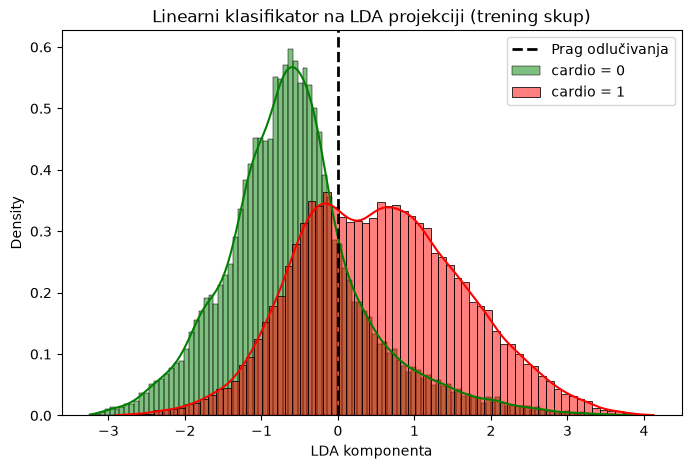

In [28]:

proj0 = proj_train[y_train == 0].reshape(-1, 1)
proj1 = proj_train[y_train == 1].reshape(-1, 1)

N0 = proj0.shape[0]
N1 = proj1.shape[0]

Z0 = np.concatenate((-proj0, -np.ones((N0, 1))), axis=1).T
Z1 = np.concatenate((proj1, np.ones((N1, 1))), axis=1).T
U = np.append(Z0, Z1, axis=1)

Gama = np.append(np.ones((N0, 1)), np.ones((N1, 1)), axis=0)

W = np.linalg.inv(U @ U.T) @ U @ Gama
v = W[0, 0]
v0 = W[1, 0]

prag = -v0 / v
print(f"Diskriminaciona funkcija: g(x) = {v:.4f} * x + {v0:.4f}")
print(f"Prag odlučivanja na LDA osi: {prag:.4f}")

plt.figure(figsize=(8, 5))
sns.histplot(proj_train[y_train == 0], color='green', label='cardio = 0', kde=True, stat='density', alpha=0.5)
sns.histplot(proj_train[y_train == 1], color='red', label='cardio = 1', kde=True, stat='density', alpha=0.5)
plt.axvline(prag, color='black', linestyle='--', linewidth=2, label='Prag odlučivanja')
plt.title('Linearni klasifikator na LDA projekciji (trening skup)')
plt.xlabel('LDA komponenta')
plt.legend()
plt.show()

### Evaluacija na nezavisnom test skupu

Matrica konfuzije:
           Predikcija 0   Predikcija 1
Stvarno 0:         5484           1517
Stvarno 1:         2394           4600

Preciznost (precision):    0.752
Senzitivnost (sensitivity/recall): 0.658
Specifičnost (specificity): 0.783
Tačnost (accuracy):        0.721


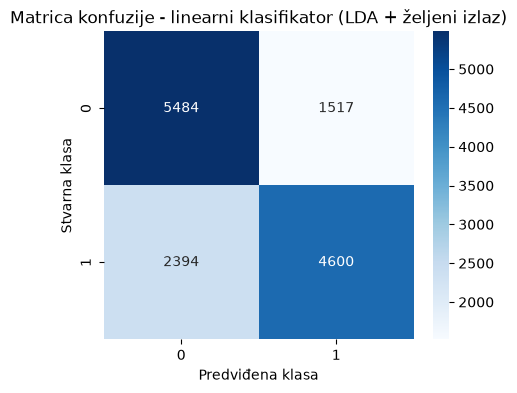

In [29]:
# Predikcija na test skupu
g_test = v * proj_test + v0
y_pred = (g_test >= 0).astype(int)

# Matrica konfuzije
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

preciznost = TP / (TP + FP)
senzitivnost = TP / (TP + FN)  
specificnost = TN / (TN + FP)
tacnost = (TP + TN) / (TP + TN + FP + FN)

print("Matrica konfuzije:")
print(f"           Predikcija 0   Predikcija 1")
print(f"Stvarno 0:   {TN:>10}   {FP:>12}")
print(f"Stvarno 1:   {FN:>10}   {TP:>12}")
print()
print(f"Preciznost (precision):    {preciznost:.3f}")
print(f"Senzitivnost (sensitivity/recall): {senzitivnost:.3f}")
print(f"Specifičnost (specificity): {specificnost:.3f}")
print(f"Tačnost (accuracy):        {tacnost:.3f}")

# Vizuelizacija matrice konfuzije
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0','1'], yticklabels=['0','1'])
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije - linearni klasifikator (LDA + željeni izlaz)')
#plt.savefig('slike/parametarski_konfuzija.png', dpi=200, bbox_inches='tight')
plt.show()

## Neparametarska klasifikacija

Biramo **stablo odlučivanja**.

### Podela na trening/test skup

In [30]:
from sklearn import tree
from sklearn.model_selection import cross_val_score

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train_nb = np.array(y_train_nb)
y_test_nb = np.array(y_test_nb)

print(f"Trening skup: {X_train_nb.shape[0]} uzoraka, test skup: {X_test_nb.shape[0]} uzoraka")
print(f"Broj obeležja: {X_train_nb.shape[1]}")

Trening skup: 55976 uzoraka, test skup: 13995 uzoraka
Broj obeležja: 13


### Krosvalidacija - optimizacija maksimalne dubine stabla

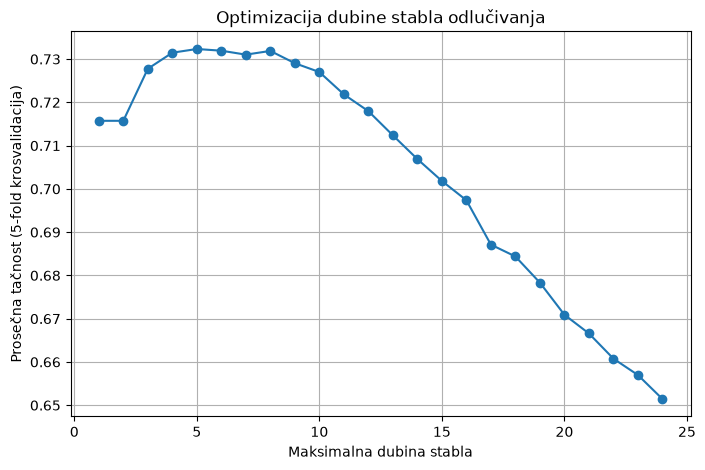

Optimalna dubina stabla: 5
Prosečna tačnost pri optimalnoj dubini: 73.23%


In [32]:
# 5-fold krosvalidacija na trening skupu za svaku vrednost dubine
depths = np.arange(1, 25)
cv_scores = []

for d in depths:
    dt = tree.DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(dt, X_train_nb, y_train_nb, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

plt.figure(figsize=(8, 5))
plt.plot(depths, cv_scores, marker='o')
plt.xlabel('Maksimalna dubina stabla')
plt.ylabel('Prosečna tačnost (5-fold krosvalidacija)')
plt.title('Optimizacija dubine stabla odlučivanja')
plt.grid()
#plt.savefig('slike/stablo_dubina.png', dpi=200, bbox_inches='tight')
plt.show()

best_depth = depths[np.argmax(cv_scores)]
print(f"Optimalna dubina stabla: {best_depth}")
print(f"Prosečna tačnost pri optimalnoj dubini: {cv_scores.max()*100:.2f}%")

### Finalni model i evaluacija na nezavisnom test skupu

Matrica konfuzije:
           Predikcija 0   Predikcija 1
Stvarno 0:         5444           1557
Stvarno 1:         2252           4742

Preciznost (precision):     0.753
Senzitivnost (sensitivity): 0.678
Specifičnost (specificity): 0.778
Tačnost (accuracy):         0.728


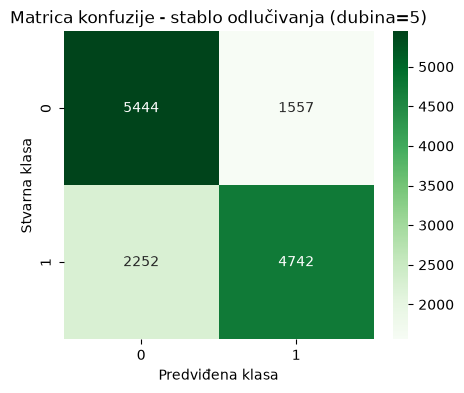

In [33]:
# Treniramo finalno stablo sa optimalnom dubinom na celom trening skupu
final_tree = tree.DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_tree.fit(X_train_nb, y_train_nb)
y_pred_tree = final_tree.predict(X_test_nb)

# Matrica konfuzije
TP = np.sum((y_pred_tree == 1) & (y_test_nb == 1))
TN = np.sum((y_pred_tree == 0) & (y_test_nb == 0))
FP = np.sum((y_pred_tree == 1) & (y_test_nb == 0))
FN = np.sum((y_pred_tree == 0) & (y_test_nb == 1))

preciznost_dt = TP / (TP + FP)
senzitivnost_dt = TP / (TP + FN)
specificnost_dt = TN / (TN + FP)
tacnost_dt = (TP + TN) / (TP + TN + FP + FN)

print("Matrica konfuzije:")
print(f"           Predikcija 0   Predikcija 1")
print(f"Stvarno 0:   {TN:>10}   {FP:>12}")
print(f"Stvarno 1:   {FN:>10}   {TP:>12}")
print()
print(f"Preciznost (precision):     {preciznost_dt:.3f}")
print(f"Senzitivnost (sensitivity): {senzitivnost_dt:.3f}")
print(f"Specifičnost (specificity): {specificnost_dt:.3f}")
print(f"Tačnost (accuracy):         {tacnost_dt:.3f}")

from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test_nb, y_pred_tree)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['0','1'], yticklabels=['0','1'])
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title(f'Matrica konfuzije - stablo odlučivanja (dubina={best_depth})')
#plt.savefig('slike/stablo_konfuzija.png', dpi=200, bbox_inches='tight')
plt.show()

### Interpretabilnost - važnost obeležja i ilustrativni prikaz stabla

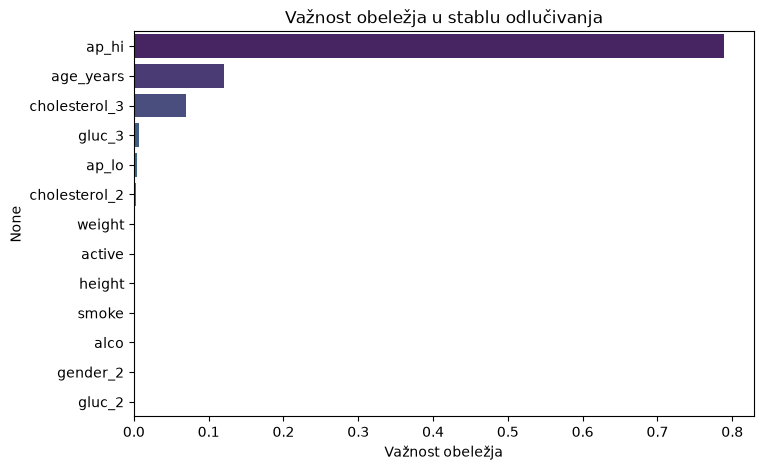

ap_hi            0.789384
age_years        0.121133
cholesterol_3    0.069458
gluc_3           0.007417
ap_lo            0.004149
cholesterol_2    0.003310
weight           0.001880
active           0.001803
height           0.001006
smoke            0.000459
alco             0.000000
gender_2         0.000000
gluc_2           0.000000
dtype: float64


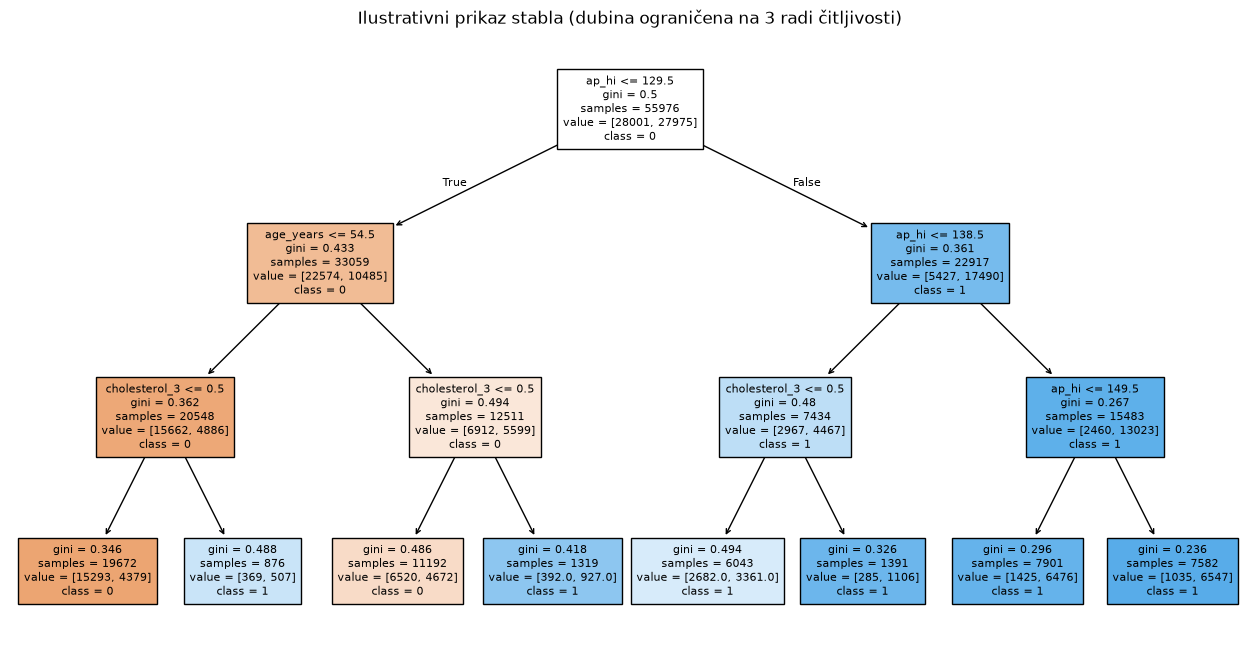

In [34]:
importances = pd.Series(final_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.xlabel('Važnost obeležja')
plt.title('Važnost obeležja u stablu odlučivanja')
#plt.savefig('slike/stablo_vaznost.png', dpi=200, bbox_inches='tight')
plt.show()

print(importances)
illustrative_tree = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
illustrative_tree.fit(X_train_nb, y_train_nb)

fig = plt.figure(figsize=(16, 8))
_ = tree.plot_tree(illustrative_tree, feature_names=X.columns, class_names=['0','1'], filled=True, fontsize=8)
plt.title('Ilustrativni prikaz stabla (dubina ograničena na 3 radi čitljivosti)')
#plt.savefig('slike/stablo_vizuelizacija.png', dpi=200, bbox_inches='tight')
plt.show()

## Neuralne mreže

In [35]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Standardizacija samo na osnovu trening skupa
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_nb)
X_test_nn = scaler_nn.transform(X_test_nb)

# Pomoćna funkcija za evaluaciju 
def evaluacija(model, X_test, y_test, naziv, boja='Purples'):
    y_pred = model.predict(X_test)
    TP = np.sum((y_pred == 1) & (y_test == 1))
    TN = np.sum((y_pred == 0) & (y_test == 0))
    FP = np.sum((y_pred == 1) & (y_test == 0))
    FN = np.sum((y_pred == 0) & (y_test == 1))

    preciznost = TP / (TP + FP)
    senzitivnost = TP / (TP + FN)
    specificnost = TN / (TN + FP)
    tacnost = (TP + TN) / (TP + TN + FP + FN)

    print(f"--- {naziv} ---")
    print(f"Tačnost: {tacnost:.3f}   Preciznost: {preciznost:.3f}   "
          f"Senzitivnost: {senzitivnost:.3f}   Specifičnost: {specificnost:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap=boja, xticklabels=['0','1'], yticklabels=['0','1'])
    plt.title(f'Matrica konfuzije - {naziv}')
    plt.xlabel('Predviđena klasa'); plt.ylabel('Stvarna klasa')
    fname = 'slike/nm_konfuzija_' + naziv.lower().replace(' ', '_').replace('-', '').replace('(', '').replace(')', '') + '.png'
    #plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

    return {'naziv': naziv, 'tacnost': tacnost, 'preciznost': preciznost,
            'senzitivnost': senzitivnost, 'specificnost': specificnost}

### Tri arhitekture: dobra, sa premalo neurona, sa previše neurona

10 ulaznih obeležja, binarna klasifikacija - orijentaciono, 'dobra' arhitektura ne treba da bude mnogo veća od par desetina neurona po sloju.

In [36]:
# A) Dobra struktura - umeren broj neurona u dva sloja
mlp_dobra = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', solver='adam',
                           alpha=0.0001, max_iter=300, random_state=42)
mlp_dobra.fit(X_train_nn, y_train_nb)

# B) Premalo neurona - kapacitet nedovoljan da nauči obrazac (underfitting)
mlp_malo = MLPClassifier(hidden_layer_sizes=(2,), activation='relu', solver='adam',
                          alpha=0.0001, max_iter=300, random_state=42)
mlp_malo.fit(X_train_nn, y_train_nb)

# C) Previše neurona, BEZ zaštite - kapacitet mnogo veći nego što je problemu potrebno (overfitting rizik)
mlp_veliko_bez_zastite = MLPClassifier(hidden_layer_sizes=(256, 256, 256), activation='relu', solver='adam',
                                        alpha=1e-8, max_iter=500, early_stopping=False, random_state=42)
mlp_veliko_bez_zastite.fit(X_train_nn, y_train_nb)

for model, naziv in [(mlp_dobra, 'Dobra struktura'), (mlp_malo, 'Premalo neurona'),
                      (mlp_veliko_bez_zastite, 'Previše neurona (bez zaštite)')]:
    acc_train = model.score(X_train_nn, y_train_nb)
    acc_test = model.score(X_test_nn, y_test_nb)
    print(f"{naziv:35s}  trening tačnost: {acc_train*100:.2f}%   test tačnost: {acc_test*100:.2f}%")

Dobra struktura                      trening tačnost: 73.98%   test tačnost: 72.80%
Premalo neurona                      trening tačnost: 73.24%   test tačnost: 72.18%
Previše neurona (bez zaštite)        trening tačnost: 89.86%   test tačnost: 66.49%


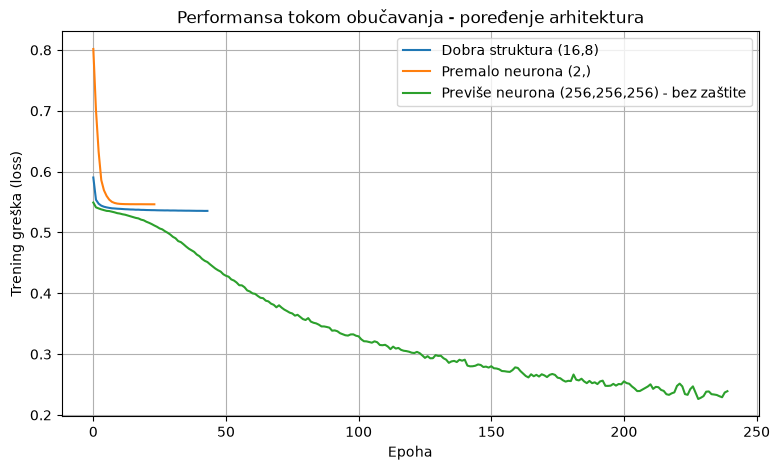

In [37]:
plt.figure(figsize=(9, 5))
plt.plot(mlp_dobra.loss_curve_, label='Dobra struktura (16,8)')
plt.plot(mlp_malo.loss_curve_, label='Premalo neurona (2,)')
plt.plot(mlp_veliko_bez_zastite.loss_curve_, label='Previše neurona (256,256,256) - bez zaštite')
plt.xlabel('Epoha')
plt.ylabel('Trening greška (loss)')
plt.title('Performansa tokom obučavanja - poređenje arhitektura')
plt.legend()
plt.grid()
#plt.savefig('slike/nm_loss_krive.png', dpi=200, bbox_inches='tight')
plt.show()

### Zaštita od preobučavanja: rano zaustavljanje i regularizacija

Mreža sa previše neurona (256,256,256) ima veliki kapacitet i sklona je preobučavanju - vidi se po tome što je trening tačnost visoka a razlika prema test tačnosti veća nego kod ostalih arhitektura. Primenjujemo dve mere zaštite:

- **Rano zaustavljanje (early stopping)**: tokom obučavanja se izdvoji deo trening skupa kao validacioni; obučavanje se prekida čim validaciona greška prestane da se poboljšava, pre nego što mreža počne da 'pamti' šum iz trening skupa.
- **Regularizacija (L2)**: kroz parametar `alpha` se dodaje kazna na velike težine u funkciji greške, što sprečava mrežu da se prilagodi previše specifičnim detaljima trening skupa.

Previše neurona SA zaštitom  -  trening tačnost: 74.15%   test tačnost: 72.90%
Broj epoha do zaustavljanja: 27 (od maksimalnih 500)


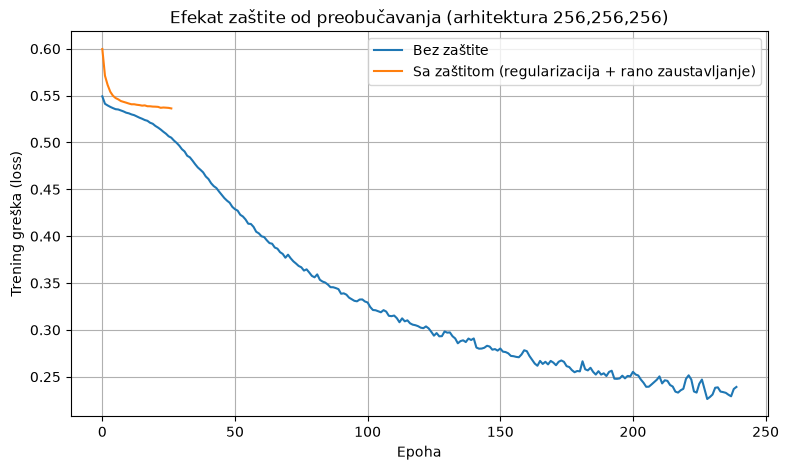


Razlika (trening - test tačnost) BEZ zaštite: 23.38 p.p.
Razlika (trening - test tačnost) SA zaštitom:  1.25 p.p.


In [39]:
# Ista arhitektura (256,256,256), ali sa zaštitom
mlp_veliko_sa_zastitom = MLPClassifier(hidden_layer_sizes=(256, 256, 256), activation='relu', solver='adam',
                                        alpha=0.05, max_iter=500, early_stopping=True,
                                        validation_fraction=0.15, n_iter_no_change=15, random_state=42)
mlp_veliko_sa_zastitom.fit(X_train_nn, y_train_nb)

acc_train_zast = mlp_veliko_sa_zastitom.score(X_train_nn, y_train_nb)
acc_test_zast = mlp_veliko_sa_zastitom.score(X_test_nn, y_test_nb)
print(f"Previše neurona SA zaštitom  -  trening tačnost: {acc_train_zast*100:.2f}%   "
      f"test tačnost: {acc_test_zast*100:.2f}%")
print(f"Broj epoha do zaustavljanja: {len(mlp_veliko_sa_zastitom.loss_curve_)} "
      f"(od maksimalnih {mlp_veliko_sa_zastitom.max_iter})")

plt.figure(figsize=(9, 5))
plt.plot(mlp_veliko_bez_zastite.loss_curve_, label='Bez zaštite')
plt.plot(mlp_veliko_sa_zastitom.loss_curve_, label='Sa zaštitom (regularizacija + rano zaustavljanje)')
plt.xlabel('Epoha')
plt.ylabel('Trening greška (loss)')
plt.title('Efekat zaštite od preobučavanja (arhitektura 256,256,256)')
plt.legend()
plt.grid()
#plt.savefig('slike/nm_zastita.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nRazlika (trening - test tačnost) BEZ zaštite: "
      f"{(mlp_veliko_bez_zastite.score(X_train_nn, y_train_nb) - mlp_veliko_bez_zastite.score(X_test_nn, y_test_nb))*100:.2f} p.p.")
print(f"Razlika (trening - test tačnost) SA zaštitom:  "
      f"{(acc_train_zast - acc_test_zast)*100:.2f} p.p.")

### Evaluacija tri finalne arhitekture na nezavisnom test skupu


--- NM - dobra struktura ---
Tačnost: 0.728   Preciznost: 0.744   Senzitivnost: 0.695   Specifičnost: 0.761


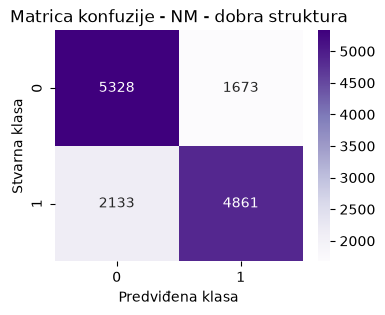

--- NM - premalo neurona ---
Tačnost: 0.722   Preciznost: 0.736   Senzitivnost: 0.690   Specifičnost: 0.753


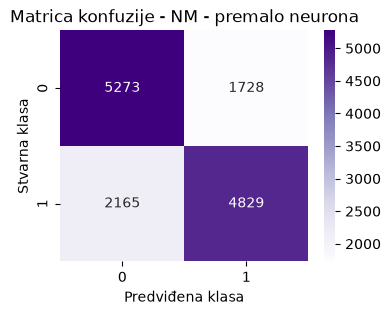

--- NM - previše neurona (sa zaštitom) ---
Tačnost: 0.729   Preciznost: 0.744   Senzitivnost: 0.697   Specifičnost: 0.761


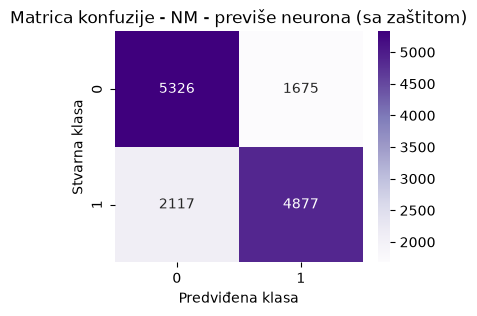

,naziv,tacnost,preciznost,senzitivnost,specificnost
0,NM - dobra struktura,0.728046,0.743955,0.695024,0.761034
1,NM - premalo neurona,0.721829,0.736465,0.690449,0.753178
2,NM - previše neurona (sa zaštitom),0.729046,0.744353,0.697312,0.760748


In [40]:
rezultati_nn = []
rezultati_nn.append(evaluacija(mlp_dobra, X_test_nn, y_test_nb, 'NM - dobra struktura'))
rezultati_nn.append(evaluacija(mlp_malo, X_test_nn, y_test_nb, 'NM - premalo neurona'))
rezultati_nn.append(evaluacija(mlp_veliko_sa_zastitom, X_test_nn, y_test_nb, 'NM - previše neurona (sa zaštitom)'))

pd.DataFrame(rezultati_nn)

## Komparativna analiza

In [41]:
komparativna_tabela = pd.DataFrame([
    {'Metoda': 'Parametarska - linearni klasifikator (LDA + željeni izlaz)',
     'Tačnost': tacnost, 'Preciznost': preciznost,
     'Senzitivnost': senzitivnost, 'Specifičnost': specificnost},
    {'Metoda': 'Neparametarska - stablo odlučivanja',
     'Tačnost': tacnost_dt, 'Preciznost': preciznost_dt,
     'Senzitivnost': senzitivnost_dt, 'Specifičnost': specificnost_dt},
])

for r in rezultati_nn:
    komparativna_tabela = pd.concat([komparativna_tabela, pd.DataFrame([{
        'Metoda': r['naziv'], 'Tačnost': r['tacnost'], 'Preciznost': r['preciznost'],
        'Senzitivnost': r['senzitivnost'], 'Specifičnost': r['specificnost']
    }])], ignore_index=True)

# Zaokruživanje radi čitljivosti
komparativna_tabela_prikaz = komparativna_tabela.copy()
for kol in ['Tačnost', 'Preciznost', 'Senzitivnost', 'Specifičnost']:
    komparativna_tabela_prikaz[kol] = (komparativna_tabela_prikaz[kol] * 100).round(2)

komparativna_tabela_prikaz

,Metoda,Tačnost,Preciznost,Senzitivnost,Specifičnost
0,Parametarska - linearni klasifikator (LDA + že...,72.05,75.20,65.77,78.33
1,Neparametarska - stablo odlučivanja,72.78,75.28,67.80,77.76
2,NM - dobra struktura,72.80,74.40,69.50,76.10
3,NM - premalo neurona,72.18,73.65,69.04,75.32
4,NM - previše neurona (sa zaštitom),72.90,74.44,69.73,76.07


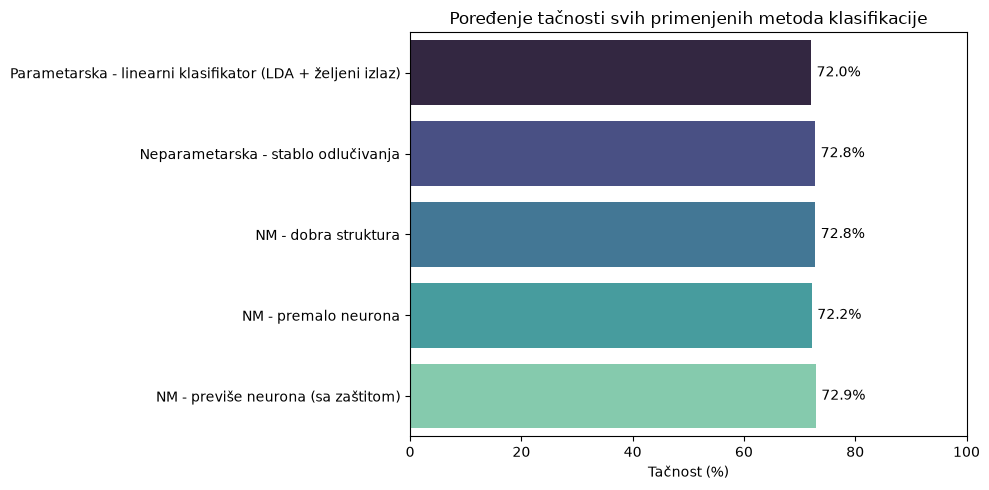


Najbolja tačnost: NM - previše neurona (sa zaštitom) sa 72.90%


In [42]:
plt.figure(figsize=(10, 5))
sns.barplot(data=komparativna_tabela_prikaz, x='Tačnost', y='Metoda', hue='Metoda', palette='mako', legend=False)
plt.xlabel('Tačnost (%)')
plt.ylabel('')
plt.title('Poređenje tačnosti svih primenjenih metoda klasifikacije')
plt.xlim(0, 100)
for i, v in enumerate(komparativna_tabela_prikaz['Tačnost']):
    plt.text(v + 1, i, f'{v:.1f}%', va='center')
plt.tight_layout()
#plt.savefig('slike/komparativna_tacnost.png', dpi=200, bbox_inches='tight')
plt.show()

najbolja = komparativna_tabela_prikaz.loc[komparativna_tabela_prikaz['Tačnost'].idxmax()]
print(f"\nNajbolja tačnost: {najbolja['Metoda']} sa {najbolja['Tačnost']:.2f}%")